In [1]:
import os
import geopandas as gpd
from dataprocess import Map
import pandas as pd
from matplotlib import pyplot as plt
from dataprocess import kringing

In [2]:
file_path_shp = os.path.join(".", "数据", "湘潭县界.shp")

kringing(pd.read_excel(os.path.join(".", "数据", "水稻点位148.xlsx")), 100)

file_path_df = os.path.join(".", "数据", "水稻点位148.xlsx")
file_path_kringing = os.path.join(".", "kringing", "data.xlsx")

c:\Codes\agricultural-decision-system\.venv\lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Codes\agricultural-decision-system\.venv\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '有效态Cd' to '有效态C'
  ogr_write(


插值数据保存成功！


In [3]:
map = Map(file_path_shp)

In [4]:
map.gdf

,县代码,省代码,市代码,县名称,市名称,省名称,xcode,经1,经2,纬1,纬2,geometry
0,430321,430000,430300,湘潭县,湘潭市,湖南省,430321.0,112.421278,113.058939,27.338039,27.94195,"POLYGON ((112.64099 27.87982, 112.6438 27.8796..."


In [5]:
map.grid_paint(grid_row=30,grid_col=30)

In [6]:
grid = map.grid

In [7]:
grid.load_dots(pd.read_excel(file_path_kringing))
grid.load_dots(pd.read_excel(file_path_df))
grid.set_focus()

<Axes: >

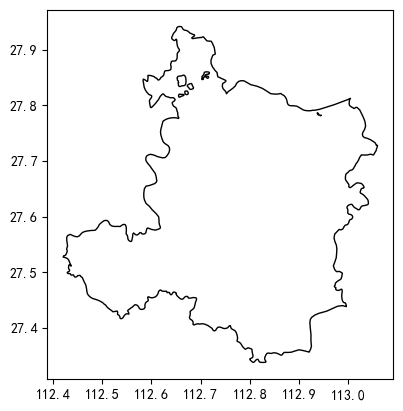

In [8]:
fig, ax = plt.subplots()
map.gdf.plot(ax=ax, facecolor="none", edgecolor="black")

In [9]:
grid.cell_matrix

[[Cell(lon=112.43190575999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.45316111999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.47441647999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.49567184, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.5169272, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.53818256, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.55943792, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.58069327999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.60194863999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.623204, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.64445936, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.66571472, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.68697008, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.70822543999999, lat=27.348104372999998, is_valid=False),
  Cell(lon=112.72948079999999, lat=27.34810

In [10]:
grid.set_value_matrix("Fe")

In [11]:
bounds = map.outline.bounds
bounds = [bounds[0],bounds[2],bounds[1],bounds[3]]


img = ax.imshow(map.grid.value_matrix, extent=bounds, origin="lower", alpha=0.5)

In [12]:
map.gdf.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_xlim(bounds[:2])
ax.set_ylim(bounds[2:])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(img, ax=ax)

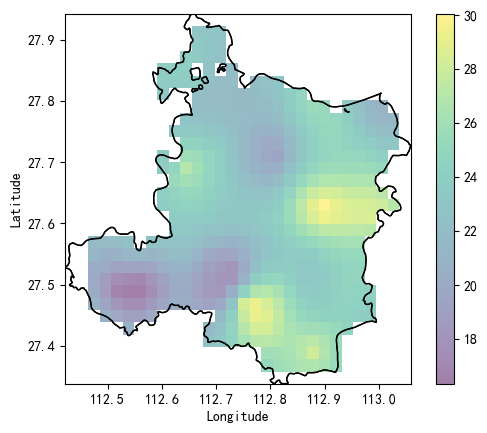

In [13]:
fig

In [14]:
plt.show()

In [15]:
fig.savefig("./Images/img.png")